In [3]:
from torchvision import transforms

transforms = transforms.Compose([
        transforms.RandomRotation(50,fill=1),
        transforms.RandomResizedCrop((224,224)),
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ToTensor(),     
])


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from application.dataset.CustomDataset import CustomDataset
from torchvision import transforms
import torch

transform_pipeline = transforms.Compose([
    transforms.RandomResizedCrop((512, 512)),  
    transforms.ToTensor()
])

def get_train_test_dataloader(batch_size):
    df = pd.read_csv("dataset.csv")

    psoriasis_idx = df[df["labels"] == "psoriasis"].index.tolist()
    outra_classe_idx = df[df["labels"] != "psoriasis"].index.tolist()

    psoriasis_train_idx, psoriasis_test_idx = train_test_split(
        psoriasis_idx, test_size=0.2, random_state=42, stratify=df.loc[psoriasis_idx, "labels"]
    )

    train_idx = psoriasis_train_idx
    test_idx = psoriasis_test_idx + outra_classe_idx

    train_dataset = Subset(CustomDataset("dataset.csv", transform_pipeline, None), train_idx)
    test_dataset = Subset(CustomDataset("dataset.csv", transform_pipeline, None), test_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),  # [B, 64, 256, 256]
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # [B, 128, 128, 128]
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # [B, 256, 64, 64]
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # [B, 128, 128, 128]
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # [B, 64, 256, 256]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),     # [B, 3, 512, 512]
            nn.Sigmoid()
        )
        
    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [ ]:
from tqdm import tqdm

def train_autoencoder(model, dataloader, optimizer, criterion, device,epoch, epochs):
    model.train()
    running_loss = 0.0 

    loop = tqdm(dataloader, desc=f"Epoch {epoch}/{epochs}", leave=True)        
    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

In [7]:
def evaluate_autoencoder(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
    return total_loss / len(dataloader.dataset)

In [28]:
from torch.utils.data import DataLoader, random_split
from itertools import product

def grid_search_autoencoder(param_grid, model_class, device='cuda'):
    best_loss = float('inf')
    best_params = None
    results = []

    keys, values = zip(*param_grid.items())
    for combination in product(*values):
        params = dict(zip(keys, combination))
        print(f"Testando configuração: {params}")

        train_loader, val_loader = get_train_test_dataloader(params['batch_size'])

        model = model_class().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        criterion = torch.nn.MSELoss()

        for epoch in range(params['epochs']):
            train_autoencoder(model, train_loader, optimizer, criterion, device, epoch, params['epochs'])

        val_loss = evaluate_autoencoder(model, val_loader, criterion, device)
        print(f"Erro de validação: {val_loss:.4f}")

        results.append((params, val_loss))
        if val_loss < best_loss:
            best_loss = val_loss
            best_params = params

    print(f"\nMelhores hiperparâmetros: {best_params} com erro {best_loss:.4f}")
    return best_params, results

In [16]:
print(f"Número de amostras de treino: {len(train_dataset)}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Número de batches: {len(train_loader)}")

Número de amostras de treino: 1404
Batch size: 32
Número de batches: 44


# modo novo (grid search)

In [29]:
param_grid = {
    'lr': [1e-2, 5e-3, 1e-3, 5e-4, 1e-4],
    'batch_size': [16, 32, 64],
    'epochs': [10, 20, 30],
    'weight_decay': [0, 1e-6, 1e-5, 1e-4],

    # otimizadores
    'optimizer': ['adam', 'sgd'],

    # funções de ativação
    'activation': ['relu', 'leaky_relu'],

    # uso de scheduler
    'scheduler': [None, 'StepLR', 'ReduceLROnPlateau'],

    # step_size e gamma para StepLR (usado se scheduler == 'StepLR')
    'step_size': [5, 10],
    'gamma': [0.1, 0.5],

    # dropout rate (se for incluir dropout nas camadas)
    'dropout': [0.0, 0.2, 0.5],

    # número de filtros iniciais no encoder (escala a profundidade)
    'base_channels': [32, 64, 128]
}


In [30]:
best_params, all_results = grid_search_autoencoder(param_grid, ConvAutoencoder, device='cpu')

Testando configuração: {'lr': 0.01, 'batch_size': 16, 'epochs': 10, 'weight_decay': 0, 'optimizer': 'adam', 'activation': 'relu', 'scheduler': None, 'step_size': 5, 'gamma': 0.1, 'dropout': 0.0, 'base_channels': 32}
[DEBUG] Lendo CSV de: dataset.csv
[DEBUG] Lendo CSV de: dataset.csv


Epoch 0/10:   0%|          | 0/88 [00:06<?, ?it/s]


UnboundLocalError: cannot access local variable 'running_loss' where it is not associated with a value

# modo antigo

In [49]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ConvAutoencoder()
train_autoencoder(model, train_loader, epochs=1, device=device)

Epoch 1/1:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1/1: 100%|██████████| 44/44 [09:36<00:00, 13.10s/it]

Epoch 1/1, Loss: 0.017269


In [50]:
errors = evaluate_autoencoder(model, test_loader, device=device)

100%|██████████| 45/45 [04:23<00:00,  5.85s/it]


In [ ]:

# labels: 1 = normal (psoríase), 0 = anomalia
true_labels = [1 if df.iloc[i]['labels'] == 'psoriasis' else 0 for i in (test_idx + outra_classe_idx)]
pred_labels = (errors < threshold).astype(int)

print(classification_report(true_labels, pred_labels, target_names=["dermatite", "psoriasis"]))

In [57]:
import matplotlib.pyplot as plt

def show_reconstructions(model, dataloader, device='cpu'):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)

    images = images.cpu()
    outputs = outputs.cpu()

    for i in range(2):
        fig, ax = plt.subplots(1, 2)
        ax[0].imshow(images[i].permute(1,2,0))
        ax[0].set_title("Original")
        ax[1].imshow(outputs[i].permute(1,2,0))
        ax[1].set_title("Reconstrução")
        plt.show()


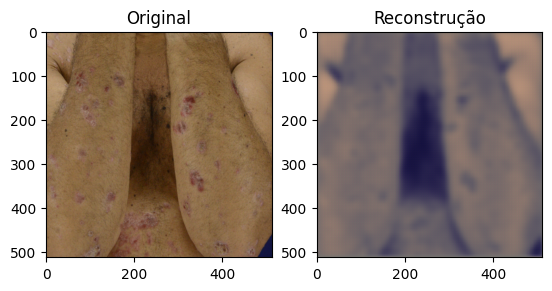

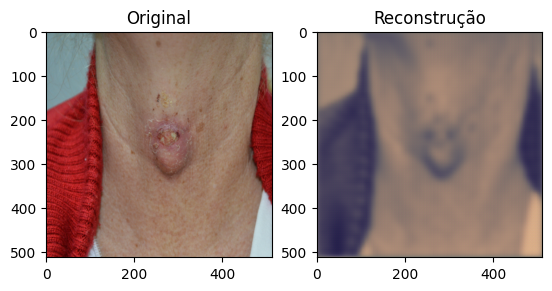

In [58]:
show_reconstructions(model, test_loader)